# 05B_Global_Adoption_StackOverflow

Build Global Adoption Score from StackOverflow survey data and create master_skill_dataset_v5.csv

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.preprocessing import MinMaxScaler

In [45]:
master = pd.read_csv('master_skill_dataset_v3.csv')
stack = pd.read_csv('survey_results_public.csv', low_memory=False)
print(master.shape)
print(stack.shape)

(35, 7)
(65437, 114)


In [46]:
TECH_SKILLS = master['skill'].tolist()
TECH_SKILLS

['aws',
 'azure',
 'c#',
 'c++',
 'django',
 'docker',
 'fastapi',
 'flask',
 'gcp',
 'go',
 'java',
 'javascript',
 'kubernetes',
 'langchain',
 'llm',
 'mongodb',
 'mysql',
 'next.js',
 'node.js',
 'numpy',
 'pandas',
 'postgresql',
 'power bi',
 'python',
 'pytorch',
 'rag',
 'react',
 'redis',
 'rust',
 'scikit-learn',
 'spark',
 'sql',
 'tableau',
 'tensorflow',
 'typescript']

In [47]:
skill_columns = ['LanguageHaveWorkedWith','DatabaseHaveWorkedWith','PlatformHaveWorkedWith','WebframeHaveWorkedWith','ToolsTechHaveWorkedWith','MiscTechHaveWorkedWith']
stack['all_skills'] = stack[skill_columns].fillna('').agg(';'.join, axis=1)

In [48]:
SKILL_MAP = {

    'python':'LanguageHaveWorkedWith',
    'javascript':'LanguageHaveWorkedWith',
    'typescript':'LanguageHaveWorkedWith',
    'java':'LanguageHaveWorkedWith',
    'c++':'LanguageHaveWorkedWith',
    'c#':'LanguageHaveWorkedWith',
    'go':'LanguageHaveWorkedWith',
    'rust':'LanguageHaveWorkedWith',

    'sql':'DatabaseHaveWorkedWith',
    'mysql':'DatabaseHaveWorkedWith',
    'postgresql':'DatabaseHaveWorkedWith',
    'mongodb':'DatabaseHaveWorkedWith',

    'react':'WebframeHaveWorkedWith',
    'next.js':'WebframeHaveWorkedWith',
    'django':'WebframeHaveWorkedWith',
    'flask':'WebframeHaveWorkedWith',

    'docker':'ToolsTechHaveWorkedWith',
    'kubernetes':'ToolsTechHaveWorkedWith',

    'aws':'PlatformHaveWorkedWith',
    'azure':'PlatformHaveWorkedWith',
    'gcp':'PlatformHaveWorkedWith',

    'tensorflow':'MiscTechHaveWorkedWith',
    'pytorch':'MiscTechHaveWorkedWith',

    'pandas':'MiscTechHaveWorkedWith',
    'numpy':'MiscTechHaveWorkedWith',

    'redis':'DatabaseHaveWorkedWith',
    'node.js':'WebframeHaveWorkedWith',

    'fastapi':'WebframeHaveWorkedWith',
    'langchain':'MiscTechHaveWorkedWith',
    'rag':'MiscTechHaveWorkedWith',
    'llm':'MiscTechHaveWorkedWith',
    
    'scikit-learn':'MiscTechHaveWorkedWith',
    'xgboost':'MiscTechHaveWorkedWith',
    'lightgbm':'MiscTechHaveWorkedWith',
    'streamlit':'WebframeHaveWorkedWith'
}


In [49]:
from scipy.stats import entropy
import re

SKILL_SEARCH = {

    'aws':'Amazon Web Services (AWS)',
    'azure':'Microsoft Azure',
    'gcp':'Google Cloud',

    'javascript':'JavaScript',
    'typescript':'TypeScript',

    'node.js':'Node.js',

    'postgresql':'PostgreSQL',
    'mysql':'MySQL',

    'c#':'C#',
    'c++':'C++',

    'react':'React',
    'python':'Python',
    'java':'Java'
}

rows = []

total_countries = stack[
    'Country'
].nunique()

print(
    f'Total Countries: {total_countries}'
)

for skill in TECH_SKILLS:

    column = SKILL_MAP.get(
        skill,
        None
    )

    if column is None:

        rows.append([
            skill,
            0,
            0,
            0
        ])

        continue

    search_term = SKILL_SEARCH.get(
        skill,
        skill
    )

    pattern = (
        rf'(^|;)'
        f'{re.escape(search_term)}'
        rf'(;|$)'
    )

    subset = stack[
        stack[column]
        .fillna('')
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    ]

    countries_present = subset[
        'Country'
    ].nunique()

    if len(subset) == 0:

        rows.append([
            skill,
            0,
            0,
            0
        ])

        continue

    country_distribution = (

        subset[
            'Country'
        ]

        .value_counts(
            normalize=True
        )

    )

    diversity_score = entropy(
        country_distribution
    )

    rows.append([

        skill,

        countries_present,

        countries_present /
        total_countries,

        diversity_score

    ])

Total Countries: 185


C:\Users\Saanvi\AppData\Local\Temp\ipykernel_9400\321266914.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\Saanvi\AppData\Local\Temp\ipykernel_9400\321266914.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\Saanvi\AppData\Local\Temp\ipykernel_9400\321266914.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\Saanvi\AppData\Local\Temp\ipykernel_9400\321266914.py:68: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(
C:\Users\Saanvi\AppData\Local\Temp\ipykernel_9400\321266914.py:68: UserWarning: This pattern is interpreted as a regular expression,

In [50]:
global_adoption = pd.DataFrame(rows, columns=['skill','countries_present','country_coverage','country_entropy'])
global_adoption.head()

,skill,countries_present,country_coverage,country_entropy
0,aws,160,0.864865,3.440464
1,azure,143,0.772973,3.511612
2,c#,163,0.881081,3.612172
3,c++,158,0.854054,3.483389
4,django,147,0.794595,3.707874


In [51]:
scaler = MinMaxScaler()

global_adoption[
    'country_entropy'
] = scaler.fit_transform(

    global_adoption[
        ['country_entropy']
    ]

)

global_adoption[
    'global_adoption_score'
] = (

    0.5 *
    global_adoption[
        'country_coverage'
    ]

    +

    0.5 *
    global_adoption[
        'country_entropy'
    ]

)

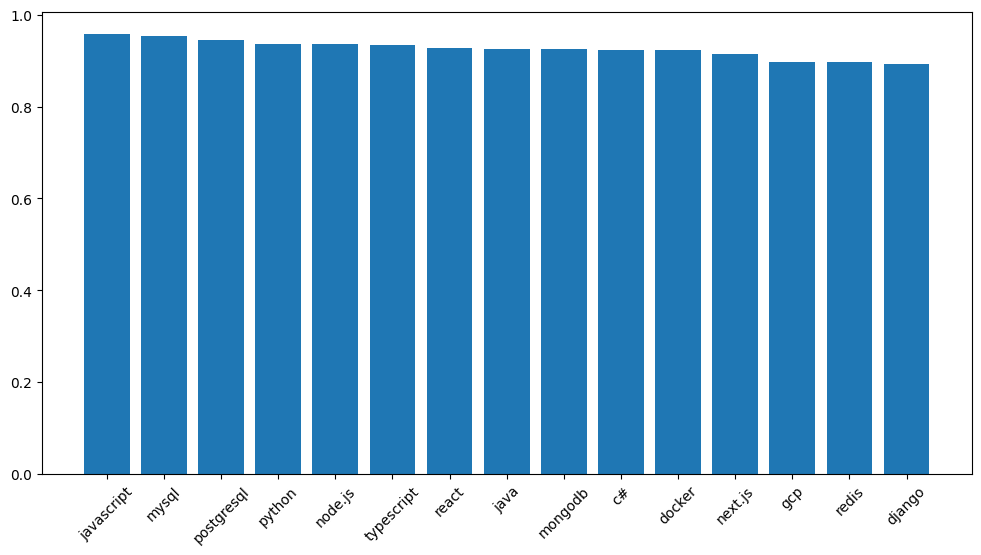

In [52]:
import matplotlib.pyplot as plt

top = global_adoption.sort_values('global_adoption_score', ascending=False).head(15)
plt.figure(figsize=(12,6))
plt.bar(top['skill'], top['global_adoption_score'])
plt.xticks(rotation=45)
plt.show()

In [53]:
master_v5 = master.merge(global_adoption[['skill','global_adoption_score']], on='skill', how='left')

In [54]:
master_v5 = master_v5.drop(columns=['geographic_spread'], errors='ignore')
master_v5.head()

,skill,linkedin_demand,salary_premium,current_usage,future_interest,future_score,global_adoption_score
0,aws,0.502949,0.571429,0.591886,0.686924,0.640658,0.892169
1,azure,0.288271,0.497905,0.342740,0.392354,0.435488,0.855730
2,c#,0.188676,0.462857,0.435240,0.492004,0.454085,0.923221
3,c++,0.265800,0.837857,0.368799,0.414020,0.492355,0.892499
4,django,0.015208,0.527619,0.155633,0.189361,0.272566,0.892766


In [55]:
global_adoption.to_csv('global_adoption_stackoverflow.csv', index=False)
master_v5.to_csv('master_skill_dataset_v5.csv', index=False)
print('Saved Successfully')

Saved Successfully


In [56]:
global_adoption.sort_values(
    'global_adoption_score',
    ascending=False
).head(20)

,skill,countries_present,country_coverage,country_entropy,global_adoption_score
11,javascript,175,0.945946,0.970462,0.958204
16,mysql,168,0.908108,0.997500,0.952804
21,postgresql,169,0.913514,0.976055,0.944784
23,python,173,0.935135,0.937689,0.936412
18,node.js,166,0.897297,0.975251,0.936274
34,typescript,166,0.897297,0.969276,0.933287
26,react,163,0.881081,0.973128,0.927105
10,java,164,0.886486,0.963156,0.924821
15,mongodb,159,0.859459,0.989787,0.924623
2,c#,163,0.881081,0.965362,0.923221


In [57]:
master_v5.to_csv(
    'master_skill_dataset_v6.csv',
    index=False
)